Assignment 2: Deep Learning

Nama: Mikail Achmad

NIM: 24/542370/PA/23026

Kelas: KOM - B

# 0. Import

In [1]:
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten
import keras
from keras.datasets import mnist
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dropout
from keras.regularizers import l1, l2
from keras.callbacks import EarlyStopping

> Kode dari 1 hingga 2 menggunakan Kode yang ada di materi Learning Strategy: Neural Network yaitu kode untuk mengklasifikasikan MNIST dari slide Strategi Pembelajaran (halaman 14-23)

# 1. Example of ANN implementation using the keras library

## 1.1. Prepare data

In [2]:
# Dataset Iris dipakai sebagai contoh data 3 kelas untuk arsitektur ANN
iris = load_iris()
X = iris.data.astype('float32')
Y = keras.utils.to_categorical(iris.target, 3)

# split 60% train / 20% val / 20% test
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=42, stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp)

## 1.2. Define model and compile model

In [3]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 1.3. Fit Model

In [4]:
model.fit(X_train,Y_train,epochs=64,batch_size=5,validation_data=(X_val,Y_val))
model.summary()

Epoch 1/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.3333 - loss: 1.1227 - val_acc: 0.3333 - val_loss: 1.0296
Epoch 2/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.5444 - loss: 0.9802 - val_acc: 0.6667 - val_loss: 0.9173
Epoch 3/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7111 - loss: 0.8875 - val_acc: 0.7000 - val_loss: 0.8396
Epoch 4/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6667 - loss: 0.8162 - val_acc: 0.6667 - val_loss: 0.7709
Epoch 5/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6667 - loss: 0.7594 - val_acc: 0.6667 - val_loss: 0.7205
Epoch 6/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7556 - loss: 0.6998 - val_acc: 0.7667 - val_loss: 0.6652
Epoch 7/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7444 - loss: 0.6515 - val_acc: 0.7000 - val_loss: 0.6223
Epoch 8/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8333 - loss: 0.6145 - val_acc: 0.8333 - val_loss: 0.5869
Epoch 9/64
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7889 - loss:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,547 (6.05 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,032 (4.04 KB)

## 1.4. Evaluation Model

In [5]:
loss, accuracy = model.evaluate(X_test, Y_test)
print('Akurasi Testing MLP:', accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - acc: 1.0000 - loss: 0.1460
Akurasi Testing MLP: 1.0


# 2. Example implementation of a fully connected layer architecture for digit recognition

## 2.1. Load Data

In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ambil validasi dari data training, bukan dari data test
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 2.2. Define Model

In [7]:
model1 = Sequential()
model1.add(Flatten(input_shape=(28, 28, 1)))
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 2.3. Compile Model, Fit Model, Save Model, and Evaluate Model

In [8]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history = model1.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_val, y_val))
model1.save('my_model1.keras')
model1.evaluate(X_test, y_test)

Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8844 - loss: 0.4206 - val_acc: 0.9335 - val_loss: 0.2368
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9417 - loss: 0.2057 - val_acc: 0.9513 - val_loss: 0.1769
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9548 - loss: 0.1560 - val_acc: 0.9582 - val_loss: 0.1420
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9641 - loss: 0.1259 - val_acc: 0.9650 - val_loss: 0.1261
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9697 - loss: 0.1063 - val_acc: 0.9660 - val_loss: 0.1129
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9736 - loss: 0.0917 - val_acc: 0.9697 - val_loss: 0.1038
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9767 - loss: 0.0803 - val_acc: 0.9690 - val_loss: 0.1062
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9792 - loss: 0.0707 - val_acc: 0.9740 - val_loss: 0.0911
Epoch 9/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - ac

[0.0882759690284729, 0.9725000262260437]

## 2.4. Visualize Model Evaluation

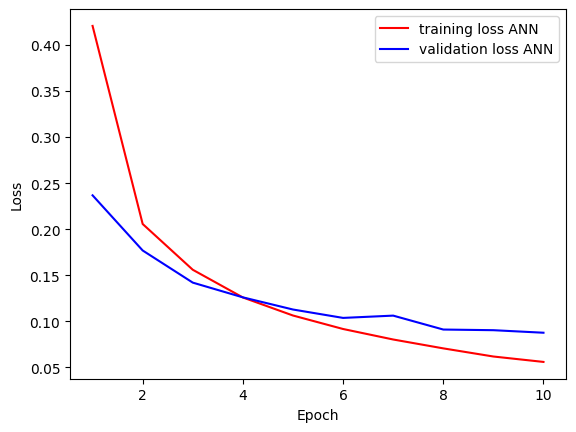

In [9]:
epochs_range = range(1, len(history.history['loss']) + 1)
loss1 = history.history['loss']
val_loss1 = history.history['val_loss']
plt.plot(epochs_range, loss1, 'r', label='training loss ANN')
plt.plot(epochs_range, val_loss1, 'b', label='validation loss ANN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 2.5. Load Model and Prediction

In [10]:
model_simpan = load_model('my_model1.keras')
pred = model_simpan.predict(X_test)
print('label actual:', np.argmax(y_test[30]))
print('label prediction:', np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 3
label prediction: 3


# 3. Regularization & Early Stopping Experiments

> Bagian ini menjawab poin (a)-(e) pada instruksi Assignment 2 dari mulai menerapkan L1, L2, Dropout, Early Stopping, hingga kombinasi L1+Dropout di atas arsitektur MLP yang sama dengan `model1` (`Flatten -> Dense(64, relu) -> Dense(10, softmax)`), memakai data MNIST yang sudah disiapkan di Bagian 2.

> Baseline di Bagian 2 dilatih 10 epoch dan overfittingnya masih tipis, sehingga susah membandingkan efek regularisasi. Di bagian ini semua model (kecuali Early Stopping) dilatih **20 epoch** agar gap train-val loss cukup terlihat. Early Stopping dilatih sampai maksimum **30 epoch** dengan `patience=3` agar training bisa berhenti lebih awal.

## 3.0. Setup: import tambahan dan helper function

In [ ]:
results = {}  # nama_model -> {'history':..., 'test_loss':..., 'test_acc':...}

def train_and_report(name, model, epochs, callbacks=None):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    model.summary()

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=100,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test)
    print(f'{name} -> test loss: {test_loss:.4f}, test acc: {test_acc:.4f}')

    epochs_range = range(1, len(history.history['loss']) + 1)
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(epochs_range, history.history['loss'], 'r', label='training loss')
    ax_loss.plot(epochs_range, history.history['val_loss'], 'b', label='validation loss')
    ax_loss.set_title(f'Loss Chart - {name}')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()

    ax_acc.plot(epochs_range, history.history['acc'], 'r', label='training acc')
    ax_acc.plot(epochs_range, history.history['val_acc'], 'b', label='validation acc')
    ax_acc.set_title(f'Accuracy Chart - {name}')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

    plt.tight_layout()
    plt.show()

    results[name] = {'history': history, 'test_loss': test_loss, 'test_acc': test_acc}
    return history

## 3.1. Baseline (tanpa regularisasi, 20 epoch)

Model dilatih ulang dari bobot baru dengan epoch 20.

In [ ]:
model_baseline = Sequential()
model_baseline.add(Flatten(input_shape=(28, 28, 1)))
model_baseline.add(Dense(64, activation='relu'))
model_baseline.add(Dense(10, activation='softmax'))

train_and_report('Baseline', model_baseline, epochs=20);

## 3.2. Eksperimen (a): L1 Regularization

Rate L1 dipilih **1e-4**, diterapkan lewat `kernel_regularizer=l1(1e-4)` pada hidden layer `Dense(64)`.

In [ ]:
L1_RATE = 1e-4

model_l1 = Sequential()
model_l1.add(Flatten(input_shape=(28, 28, 1)))
model_l1.add(Dense(64, activation='relu', kernel_regularizer=l1(L1_RATE)))
model_l1.add(Dense(10, activation='softmax'))

train_and_report('L1', model_l1, epochs=20);

## 3.3. Eksperimen (b): L2 Regularization

Rate L2 disamakan urutan magnitudenya dengan L1, yaitu **1e-4** (`kernel_regularizer=l2(1e-4)`), agar perbandingan efek menyusutkan bobot ke arah 0 (L1) dengan menyusutkan bobot secara proporsional (L2) lebih fair.

In [ ]:
L2_RATE = 1e-4

model_l2 = Sequential()
model_l2.add(Flatten(input_shape=(28, 28, 1)))
model_l2.add(Dense(64, activation='relu', kernel_regularizer=l2(L2_RATE)))
model_l2.add(Dense(10, activation='softmax'))

train_and_report('L2', model_l2, epochs=20);

## 3.4. Eksperimen (c): Dropout

Dropout rate **0.3** dipasang setelah hidden layer (`Dense(64, relu) -> Dropout(0.3) -> Dense(10, softmax)`).

In [ ]:
DROPOUT_RATE = 0.3

model_dropout = Sequential()
model_dropout.add(Flatten(input_shape=(28, 28, 1)))
model_dropout.add(Dense(64, activation='relu'))
model_dropout.add(Dropout(DROPOUT_RATE))
model_dropout.add(Dense(10, activation='softmax'))

train_and_report('Dropout', model_dropout, epochs=20);

## 3.5. Eksperimen (d): Early Stopping

`EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)`: training dihentikan kalau `val_loss` tidak membaik selama 3 epoch berturut-turut, dan bobot dikembalikan ke epoch terbaik. Epoch maksimum dinaikkan ke **30** agar callback punya kesempatan untuk trigger sebelum mentok batas atas.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8896 - loss: 0.4011 - val_acc: 0.9390 - val_loss: 0.2208
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9456 - loss: 0.1922 - val_acc: 0.9562 - val_loss: 0.1608
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9574 - loss: 0.1469 - val_acc: 0.9610 - val_loss: 0.1364
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9649 - loss: 0.1205 - val_acc: 0.9665 - val_loss: 0.1177
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9706 - loss: 0.1013 - val_acc: 0.9698 - val_loss: 0.1117
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.9752 - loss: 0.0870 - val_acc: 0.9675 - val_loss: 0.1085
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9774 - loss: 0.0769 - val_acc: 0.9728 - val_loss: 0.0990
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9806 - loss: 0.0673 - val_acc: 0.9718 - val_loss: 0.0983
Epoch 9/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

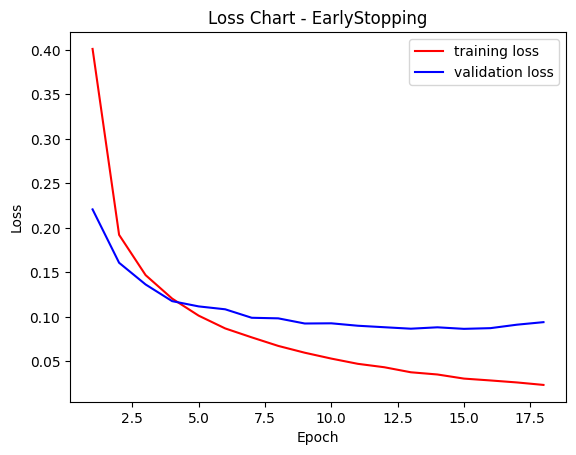

Training berhenti di epoch 18 dari maksimum 30.


In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_early = Sequential()
model_early.add(Flatten(input_shape=(28, 28, 1)))
model_early.add(Dense(64, activation='relu'))
model_early.add(Dense(10, activation='softmax'))

history_early = train_and_report('EarlyStopping', model_early, epochs=30, callbacks=[early_stop])
print(f"Training berhenti di epoch {len(history_early.history['loss'])} dari maksimum 30.")

## 3.6. Eksperimen (e): L1 Regularization + Dropout

Gabungan `kernel_regularizer=l1(1e-4)` pada `Dense(64)` dan `Dropout(0.3)` setelahnya — rate sama seperti eksperimen (a) dan (c) masing-masing, agar efek kombinasinya bisa dibandingkan langsung dengan efek tiap teknik secara individu.

In [ ]:
model_l1_dropout = Sequential()
model_l1_dropout.add(Flatten(input_shape=(28, 28, 1)))
model_l1_dropout.add(Dense(64, activation='relu', kernel_regularizer=l1(L1_RATE)))
model_l1_dropout.add(Dropout(DROPOUT_RATE))
model_l1_dropout.add(Dense(10, activation='softmax'))

train_and_report('L1+Dropout', model_l1_dropout, epochs=20);

## 3.7. Perbandingan & Kesimpulan (Tambahan)

Tabel akurasi/loss test dan grafik `val_loss` gabungan untuk semua model (Baseline + 5 eksperimen), agar gampang diidentifikasi teknik mana yang paling menekan overfitting dan bagaimana trade-off nya terhadap akurasi.

In [ ]:
# Tabel ringkas akurasi/loss test + gap overfitting pada epoch terakhir
print(f"{'Model':<15}{'Test Acc':>10}{'Test Loss':>12}{'Val-Train Loss Gap':>22}")
for name, r in results.items():
    final_train_loss = r['history'].history['loss'][-1]
    final_val_loss = r['history'].history['val_loss'][-1]
    gap = final_val_loss - final_train_loss
    print(f"{name:<15}{r['test_acc']:>10.4f}{r['test_loss']:>12.4f}{gap:>22.4f}")

# Grafik val_loss dan val_acc gabungan semua model
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    h_loss = r['history'].history['val_loss']
    h_acc = r['history'].history['val_acc']
    ax_loss.plot(range(1, len(h_loss) + 1), h_loss, label=name)
    ax_acc.plot(range(1, len(h_acc) + 1), h_acc, label=name)

ax_loss.set_title('Perbandingan Validation Loss Antar Model')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Validation Loss')
ax_loss.legend()

ax_acc.set_title('Perbandingan Validation Accuracy Antar Model')
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Validation Accuracy')
ax_acc.legend()

plt.tight_layout()
plt.show()

### **Kesimpulan Analisis Eksperimen Regularisasi & Early Stopping**

Berdasarkan hasil percobaan model di atas dengan berbagai skema pada Assignment 2, berikut adalah analisis dan jawaban dari beberapa penerapan pada bagian (2):

1. **Teknik yang paling menekan overfitting dengan mengecilkan gap val-train loss adalah Dropout (2c) dan Regulaisasi L1 sekaligus Dropout (2e).**
   * Model **L1+Dropout** menghasilkan gap paling kecil/negatif sebesar **-0.0437** (Validation Loss: 0.1846, Training Loss: 0.2282), disusul oleh **Dropout** dengan gap **-0.0107**. Gap negatif ini menunjukkan bahwa model berhasil diregulasi dengan ketat sehingga performa data validasi setara atau sedikit lebih stabil dibandingkan data training.

2. **Pengecilan gap overfitting tidak diikuti penurunan akurasi yang signifikan.**
   * Test Accuracy berada pada rentang dari **97.16% hingga 97.55%**.
   * Penurunan akurasi dari Baseline (97.55%) ke model dengan regularisasi terkuat L1+Dropout (97.16%) hanya sebesar **0.39%**, yang membuktikan bahwa model hasil regularisasi cukup tangguh tanpa mengorbankan performa klasifikasi secara berarti.

3. **Callback Early Stopping menghentikan proses training pada **epoch 18** dari maksimum 30 epoch.**
   * Artinya, performa terbaik dicapai pada epoch 15, dan tidak ada peningkatan signifikan selama 3 epoch setelahnya.
   * Hasil akhirnya sebanding dengan model yang dilatih penuh 20 epoch. Early Stopping mencatat Test Accuracy sebesar **97.30%** dengan Test Loss terendah dibanding semua variasi lainnya, yaitu **0.0888**. Ini membuktikan bahwa Early Stopping efisien dalam menghemat waktu komputasi sekaligus mencegah overfitting.